Data loaded successfully!


/tmp/ipykernel_3255/1195408555.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='Set2')


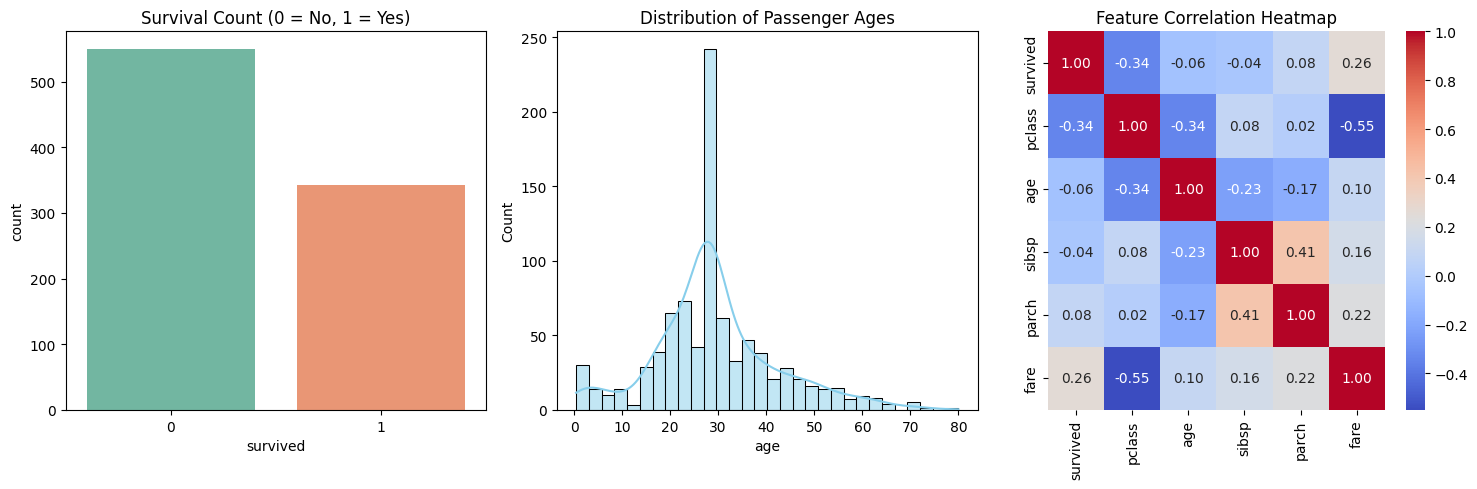


Model Accuracy: 80.45%


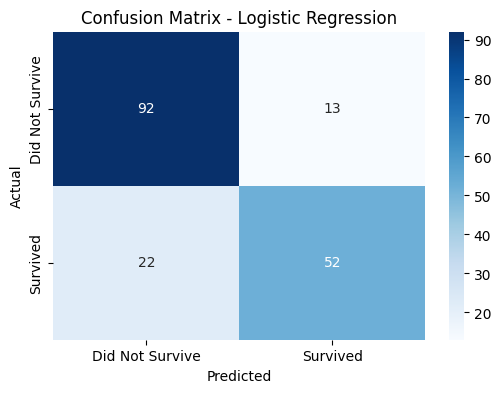

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df = sns.load_dataset('titanic')
print("Data loaded successfully!")
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town'], errors='ignore')
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='survived', data=df, palette='Set2')
plt.title('Survival Count (0 = No, 1 = Yes)')

plt.subplot(1, 3, 2)
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')

plt.subplot(1, 3, 3)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

df['FamilySize'] = df['sibsp'] + df['parch'] + 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
features = ['age', 'sex', 'pclass', 'fare', 'FamilySize']
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()